In [ ]:
gpu = False # make sure this matches in the other files
from SpectralAdvectionDiffusion import get_x_deriv,get_y_deriv,get_z_deriv
if gpu:
    print('using gpu')
    import cupy as np
    from cupy.linalg import norm
    from cupyx.scipy.special import k1
    def njit(fastmath=0):
        def decorator(func):
            def wrapper(*args, **kwargs):
                return func(*args, **kwargs)
            return wrapper
        return decorator
else:
    print('not using gpu')
    import numpy as np
    from numpy.linalg import norm
    from scipy.special import k1
    from numba import njit

from matplotlib import pyplot as plt
pi = np.pi

In [ ]:
# funcs
def get_tdesign_points(n):
    pts = np.load(f'./data/points/{n}_tsphere.npy')
    return pts

def get_cylinder_pts(n,h,r):
    # a hollow cylinder, might not be stable at the caps
    # helix method
    nrev = np.sqrt(h*n/(2*pi))
    theta = np.linspace(0,2*pi*nrev,n)
    dh_vec = np.linspace(0,h,n)
    pts = np.stack([
        r*np.cos(theta),
        r*np.sin(theta),
        dh_vec
    ], axis=1)
    return pts

def get_silo_pts(n1,n2,h,r,x0):
    '''
    n1: num of pts in cylinder part
    n2: num of pts in hemisphere part
    h: height of cylinder (not including hemisphere)
    r: radius
    x0: location (x,y,z) of center of bottom of silo
    '''
    pts1 = get_cylinder_pts(n1,h,r)
    sph_pts = get_tdesign_points(n2)
    idxs = np.where(sph_pts[:,2]>0)
    pts2 = sph_pts[idxs]
    pts2 = pts2*r + np.array([h*0,h*0,h])
    pts = np.vstack([pts1,pts2])
    pts = pts+x0
    return pts
    
def solve_ols(M,y):
    return np.linalg.lstsq(M,y)[0]

def gradG(x,xj):
    # should take a vector of points to evaluate (x) and a vector of source points (xj) and return 3 matrices: dGdx, dGdy, dGdz.
    # G = 1/||x|| -> dGdxi = -xi/||x||^3
    diffs = x[:, np.newaxis, :] - xj[np.newaxis, :, :] # diffs_inm = x_im - xj_nm
    Rsq = (diffs**2).sum(axis=2)
    Rsq[Rsq==0]=1 # to avoid grid_pts same as source_points. These get set to 0 later anyways.
    x_mirr = np.stack([x[:,0], x[:,1], -x[:,2]], axis=1)
    diffs_mirr = x_mirr[:, np.newaxis, :] - xj[np.newaxis, :, :]
    Rsq_mirr = (diffs_mirr**2).sum(axis=2)
    Rsq_mirr[Rsq_mirr==0]=1

    dGdx = -diffs[:,:,0]/Rsq**(3/2) - diffs[:,:,0]/Rsq_mirr**(3/2)
    dGdy = -diffs[:,:,1]/Rsq**(3/2) - diffs[:,:,1]/Rsq_mirr**(3/2)
    dGdz = -diffs[:,:,2]/Rsq**(3/2) + diffs_mirr[:,:,2]/Rsq_mirr**(3/2)
    return dGdx, dGdy, dGdz

def get_normal_arr(x, shape_params):
    shape = shape_params[-1]
    if shape==0:
        x0 = np.array([shape_params[0], shape_params[1], shape_params[2]])
        normals = (x - x0)/norm(x - x0, axis=1)[:,np.newaxis]
    elif shape==1:
        # relies on knowing something about the order of the points.
        x0 = np.array([shape_params[0],shape_params[1],shape_params[1]*0])
        h = shape_params[2]
        r = shape_params[3]
        n1 = np.sum(x[:,2]<h)
        n2 = len(x)-n1
        normals = np.zeros(np.shape(x))
        normals[0:n1, 0:2] = ((x - x0)/r)[0:n1, 0:2]
        normals[n1:(n1+n2)] = (x[n1:(n1+n2)] - np.array([h*0,h*0,h]) - x0)/r

    return normals

def is_interior_vec(grid_pts, params):
    shape = params[-1]
    if shape==0:
        x0 = np.array([params[0],params[1],params[2]])
        r = params[3]
        dists = np.sqrt(((grid_pts - x0)**2).sum(axis=1))
        return dists < r
    elif shape==1:
        x0 = np.array([params[0],params[1],params[1]*0])
        h = params[2]
        r = params[3]
        return ((grid_pts[:,2]<h) & (norm(np.stack([
            grid_pts[:,0],grid_pts[:,1],grid_pts[:,1]*0
            ],axis=1) - x0, axis=1) < r)) | ((grid_pts[:,2] >= h) & (norm(grid_pts-np.array([params[0],params[1],params[2]]),axis=1)<r) )

In [65]:
shape_params = np.array([3,1,4,2,1])
dx = .2
shape = shape_params[-1]
uinf = np.array([10,0,0]) # wind in x,y,z direction. Wind in z must be 0.
rs = shape_params[3]-.8
rs_int = shape_params[3]+.2
Ns = 60 # currently also using this as Ns_int. Investigate later.
Ns_int = 60
Nb = 144
Lx = 6
Lz = 6
Ly = 2

if shape==0:
    # sphere
    x0 = np.array([shape_params[0],shape_params[1],shape_params[2]])
    r = shape_params[3]
    surface_points = get_tdesign_points(Nb)*r + x0
    source_points = get_tdesign_points(Ns)*rs + x0
    source_points_int = get_tdesign_points(Ns)*rs_int + x0
elif shape==1:
    # silo
    x0 = np.array([shape_params[0],shape_params[1],shape_params[1]*0])
    h = shape_params[2]
    r = shape_params[3]
    Nb_dome = Nb
    Nb_cyl = int(np.round(h*Nb_dome/2/r))
    Ns_dome = Ns
    Ns_cyl = int(np.round(h*Ns_dome/2/rs))
    Ns_dome_int = Ns_int
    Ns_cyl_int = int(np.round(h*Ns_int/2/rs_int))
    surface_points = get_silo_pts(Nb_cyl,Nb_dome,h,r,x0)
    source_points = get_silo_pts(Ns_cyl,Ns_dome,h,rs,x0)
    source_points_int = get_silo_pts(Ns_cyl_int,Ns_dome_int,h,rs_int,x0)

    print(f'total surface pts: {len(surface_points)}')
    print(f'total src pts: {len(source_points)}')
    print(f'total interior pts: {len(source_points_int)}')

xx = np.arange(0,Lx,dx)
yy = np.arange(0,Ly,dx)
zz = np.arange(0,Lz,dx)
Y,Z,X = np.meshgrid(yy,zz,xx, indexing='ij')
grid_pts = np.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=1)
Nx = len(xx)
Ny = len(yy)
Nz = len(zz)
interior_mask = is_interior_vec(grid_pts, shape_params)

dGdx_mat_surface, dGdy_mat_surface, dGdz_mat_surface = gradG(surface_points, source_points)

normal_arr = get_normal_arr(surface_points, shape_params)
normal_arr_x = normal_arr[:,0]
normal_arr_y = normal_arr[:,1]
normal_arr_z = normal_arr[:,2]
normal_mat_x = np.repeat(normal_arr_x,len(source_points)).reshape(np.shape(dGdx_mat_surface))
normal_mat_y = np.repeat(normal_arr_y,len(source_points)).reshape(np.shape(dGdx_mat_surface))
normal_mat_z = np.repeat(normal_arr_z,len(source_points)).reshape(np.shape(dGdx_mat_surface))
M = dGdx_mat_surface * normal_mat_x + dGdy_mat_surface * normal_mat_y + dGdz_mat_surface * normal_mat_z

y = -uinf[0] * normal_arr_x - uinf[1] * normal_arr_y # remember uinf[2] = 0
alpha = solve_ols(M,y)

M_int1,M_int2,M_int3 = gradG(surface_points, source_points_int)

y_int1 = dGdx_mat_surface @ alpha + uinf[0]
y_int2 = dGdy_mat_surface @ alpha + uinf[1]
y_int3 = dGdz_mat_surface @ alpha

alpha_int_x = solve_ols(M_int1,y_int1)
alpha_int_y = solve_ols(M_int2,y_int2)
alpha_int_z = solve_ols(M_int3,y_int3)

dGdx_mat,dGdy_mat,dGdz_mat = gradG(grid_pts, source_points)
Ux = np.reshape((dGdx_mat @ alpha + uinf[0])*(~interior_mask), (Ny,Nz,Nx))
Uy = np.reshape((dGdy_mat @ alpha + uinf[1])*(~interior_mask), (Ny,Nz,Nx))
Uz = np.reshape((dGdz_mat @ alpha)*(~interior_mask), (Ny,Nz,Nx))

dGdx_mat_int, dGdy_mat_int, dGdz_mat_int = gradG(grid_pts, source_points_int)

Ux_int = np.reshape((dGdx_mat_int @ alpha_int_x)*(interior_mask), (Ny,Nz,Nx))
Uy_int = np.reshape((dGdy_mat_int @ alpha_int_y)*(interior_mask), (Ny,Nz,Nx))
Uz_int = np.reshape((dGdz_mat_int @ alpha_int_z)*(interior_mask), (Ny,Nz,Nx))
# Ux_int = 0*Ux
# Uy_int = 0*Uy
# Uz_int = 0*Uz

Ux = Ux + Ux_int
Uy = Uy + Uy_int
Uz = Uz + Uz_int

y_idx = np.argmin(np.abs(yy-shape_params[1]))

plane_x = X[y_idx,:,:]
plane_z = Z[y_idx,:,:]



total surface pts: 216
total src pts: 128
total interior pts: 83


(30, 30)
1.0


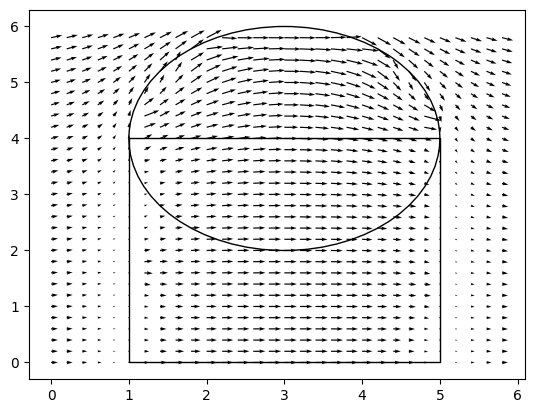

In [66]:
Ux_plane = Ux[y_idx,:,:]
Uz_plane = Uz[y_idx,:,:]

print(np.shape(plane_x))

print(yy[y_idx])
fig, ax = plt.subplots()
ax.quiver(plane_x.ravel(),plane_z.ravel(),Ux_plane,Uz_plane)
ax.add_patch(plt.Circle([shape_params[0],shape_params[2],], shape_params[3], fill=0, color='k'))
ax.add_patch(plt.Rectangle([shape_params[0]-shape_params[3],0],2*shape_params[3],shape_params[2],fill=0, color='k'))
plt.show()